In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
dataset = pd.read_csv("Social_Network_Ads.csv")

In [49]:
# dataset.head()

In [50]:
# dataset.info()

In [23]:
x = dataset["Age"]

In [24]:
x = ( x - x.mean()) / x.std()

In [25]:
y = dataset["Purchased"]

In [28]:
def log_loss(y,y_pred):
    esp = 1e-15
    y_pred = np.clip(y_pred,esp,1-esp)
    return -np.mean(y*np.log(y_pred) + (1-y)*np.log(1-y_pred))

In [29]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1+np.exp(-z))

In [58]:
m = 0
b = 0
lr = 0.01
epocsh = 100000
n = len(x)
tolerance = 1e-6

In [59]:
prev_loss = float("inf")

In [60]:
for i in range(epocsh):
    z = m*x + b
    y_pred = sigmoid(z)

    dm = (1/n) * np.sum((y_pred-y)*x)
    db = (1/n) * np.sum(y_pred-y)

    loss = log_loss(y, y_pred)

    m -= lr * dm
    b -= lr * db

    if i % 200 == 0:
        print(f"Epoch {i}, Loss = {log_loss(y, y_pred):.4f}")

    if abs(prev_loss - loss) < tolerance:
        print(f"\nTraining stopped early at epoch {i}")
        break

    prev_loss = loss

Epoch 0, Loss = 0.6931
Epoch 200, Loss = 0.5536
Epoch 400, Loss = 0.4955
Epoch 600, Loss = 0.4669
Epoch 800, Loss = 0.4510
Epoch 1000, Loss = 0.4414
Epoch 1200, Loss = 0.4352
Epoch 1400, Loss = 0.4311
Epoch 1600, Loss = 0.4282
Epoch 1800, Loss = 0.4262
Epoch 2000, Loss = 0.4248
Epoch 2200, Loss = 0.4237
Epoch 2400, Loss = 0.4229
Epoch 2600, Loss = 0.4223
Epoch 2800, Loss = 0.4219
Epoch 3000, Loss = 0.4215
Epoch 3200, Loss = 0.4213

Training stopped early at epoch 3305


In [61]:
print("Best theta0:", b)
print("Best theta1:", m)

Best theta0: -0.8623208416712264
Best theta1: 1.8285391018902688


In [66]:
print(sigmoid(z = m*x + b))

0      0.016043
1      0.209915
2      0.052386
3      0.061752
4      0.016043
         ...   
395    0.644123
396    0.812367
397    0.784322
398    0.240306
399    0.753357
Name: Age, Length: 400, dtype: float64


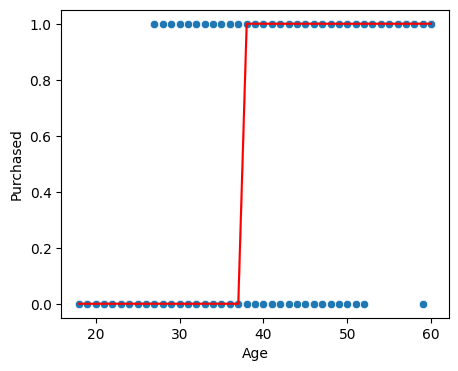

In [67]:
plt.figure(figsize=(5,4))
sns.scatterplot(x="Age",y="Purchased",data=dataset)
sns.lineplot(x="Age",y=(sigmoid(x)>=0.5).astype(int),data=dataset,color='r')
plt.show()